# **Day 31: Generative Classifiers - Naive Bayes, LDA and QDA**
*Module 5 - Classification*

So far our classifiers model $P(y\mid\mathbf x)$ directly (**discriminative**). **Generative** classifiers model how each class **generates** data, $p(\mathbf x\mid y)$, and the class priors $P(y)$, then apply **Bayes' theorem**:
$$P(y=k\mid\mathbf x) = \frac{p(\mathbf x\mid y=k)\,P(y=k)}{\sum_j p(\mathbf x\mid y=j)\,P(y=j)}$$

> Generative classifiers learn what each class "looks like" (its distribution) and then ask which class most probably produced a new sample. Naive Bayes assumes independent features, while LDA and QDA assume Gaussian classes.
>
> *Example:* The classic maximum-likelihood classifier in remote-sensing software is essentially QDA: each land-cover class is modelled as a Gaussian cloud in spectral space.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal, norm
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.model_selection import cross_val_score, train_test_split
rng = np.random.default_rng(31)

## **1. Gaussian Naive Bayes From Scratch**
"Naive" assumption: features are **conditionally independent given the class**, so $p(\mathbf x\mid y=k) = \prod_j \mathcal N(x_j;\mu_{kj},\sigma_{kj}^2)$. Training = computing means, variances and class frequencies. Very fast; works with tiny datasets and thousands of features.

In [2]:
class GaussianNBScratch:
    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.prior_ = np.array([np.mean(y == c) for c in self.classes_])
        self.mu_ = np.array([X[y == c].mean(0) for c in self.classes_])
        self.var_ = np.array([X[y == c].var(0) for c in self.classes_]) + 1e-9 * X.var(0).max()
        return self
    def _joint_log_likelihood(self, X):
        # log P(y) + sum_j log N(x_j; mu, var)   (logs avoid underflow)
        return np.log(self.prior_) + np.stack([norm.logpdf(X, self.mu_[k], np.sqrt(self.var_[k])).sum(1) for k in range(len(self.classes_))], axis=1)
    def predict_proba(self, X):
        jll = self._joint_log_likelihood(X); jll -= jll.max(1, keepdims=True)
        p = np.exp(jll); return p / p.sum(1, keepdims=True)
    def predict(self, X):
        return self.classes_[self._joint_log_likelihood(X).argmax(1)]

from sklearn.datasets import load_wine
X, y = load_wine(return_X_y=True)
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, stratify=y, random_state=0)
mine = GaussianNBScratch().fit(Xtr, ytr); lib = GaussianNB().fit(Xtr, ytr)
print(f"scratch acc {np.mean(mine.predict(Xte) == yte):.3f} | sklearn acc {lib.score(Xte, yte):.3f} | max prob difference {np.abs(mine.predict_proba(Xte) - lib.predict_proba(Xte)).max():.2e}")

scratch acc 0.963 | sklearn acc 0.963 | max prob difference 2.00e-15


## **2. Naive Bayes for Text**
Word counts -> **MultinomialNB**; word presence -> **BernoulliNB**. A classic, strong baseline for spam filtering and document classification.

In [3]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.pipeline import make_pipeline
docs = ["heavy rain flood warning river overflow", "flood water entered village homes", "river level rising flood alert",
        "dry spell drought crop failure", "no rain drought water scarcity wells dry", "drought relief for farmers crop loss",
        "cyclone wind landfall coast evacuation", "strong wind cyclone storm surge coast", "cyclone alert fishermen coast"]
labels = ["flood"] * 3 + ["drought"] * 3 + ["cyclone"] * 3
nb_text = make_pipeline(CountVectorizer(), MultinomialNB(alpha=1.0)).fit(docs, labels)
tests = ["river flood near village", "crop loss due to no rain", "storm surge expected at coast"]
for t, p in zip(tests, nb_text.predict(tests)):
    print(f"{t:<35} -> {p}")
vocab = nb_text[0].get_feature_names_out(); logp = nb_text[1].feature_log_prob_
for k, c in enumerate(nb_text[1].classes_):
    print(f"Top words for {c}: {list(vocab[np.argsort(logp[k])[::-1][:4]])}")

river flood near village            -> flood
crop loss due to no rain            -> drought
storm surge expected at coast       -> cyclone
Top words for cyclone: ['cyclone', 'coast', 'wind', 'evacuation']
Top words for drought: ['drought', 'dry', 'crop', 'wells']
Top words for flood: ['flood', 'river', 'entered', 'heavy']


`alpha=1` is **Laplace smoothing**: it adds a pseudo-count so an unseen word does not make a probability exactly zero.

## **3. QDA = The Maximum Likelihood Classifier (MLC)**
Drop the independence assumption: each class is a full multivariate Gaussian $\mathcal N(\boldsymbol\mu_k, \Sigma_k)$. The log-posterior is quadratic in $\mathbf x$, so boundaries are **quadratic curves**. In remote sensing this is the **Maximum Likelihood Classifier**, the standard method for decades.

## **4. LDA: Shared Covariance -> Linear Boundaries**
If all classes share one covariance $\Sigma$, the quadratic terms cancel and boundaries become **linear**. Fewer parameters ($p^2/2$ instead of $Kp^2/2$) -> more stable with small samples.

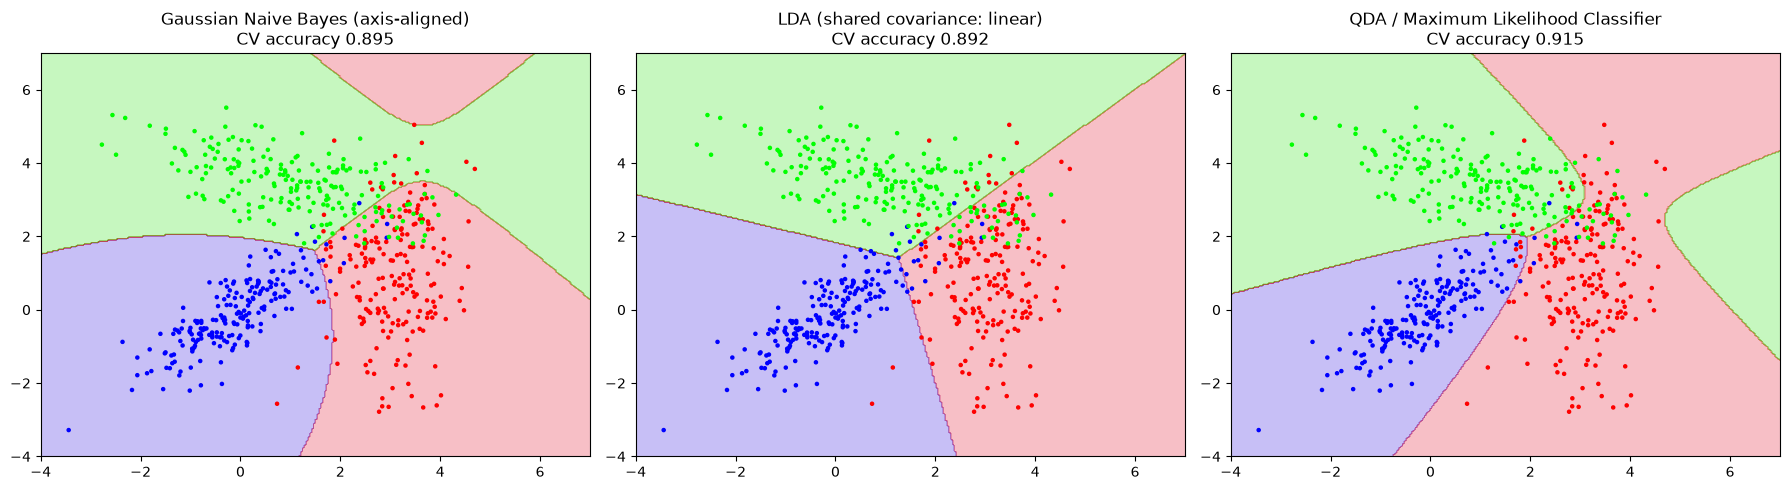

In [4]:
means = [np.array([0, 0]), np.array([3, 1]), np.array([1, 3.5])]
covs = [np.array([[1, 0.8], [0.8, 1]]), np.array([[0.4, 0], [0, 2]]), np.array([[2, -0.6], [-0.6, 0.6]])]
X2 = np.vstack([rng.multivariate_normal(m, c, 200) for m, c in zip(means, covs)]); y2 = np.repeat([0, 1, 2], 200)
xx, yy = np.meshgrid(np.linspace(-4, 7, 300), np.linspace(-4, 7, 300)); grid = np.c_[xx.ravel(), yy.ravel()]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, m) in zip(axes, {"Gaussian Naive Bayes (axis-aligned)": GaussianNB(), "LDA (shared covariance: linear)": LinearDiscriminantAnalysis(),
                                 "QDA / Maximum Likelihood Classifier": QuadraticDiscriminantAnalysis()}.items()):
    m.fit(X2, y2)
    ax.contourf(xx, yy, m.predict(grid).reshape(xx.shape), alpha=0.25, cmap="brg")
    ax.scatter(*X2.T, c=y2, cmap="brg", s=5)
    ax.set_title(f"{name}\nCV accuracy {cross_val_score(m, X2, y2, cv=5).mean():.3f}")
plt.tight_layout(); plt.show()

## **5. LDA as Supervised Dimensionality Reduction**
LDA finds at most $K-1$ directions that **maximise between-class separation relative to within-class spread** (Fisher, 1936). Unlike PCA, it uses the labels.

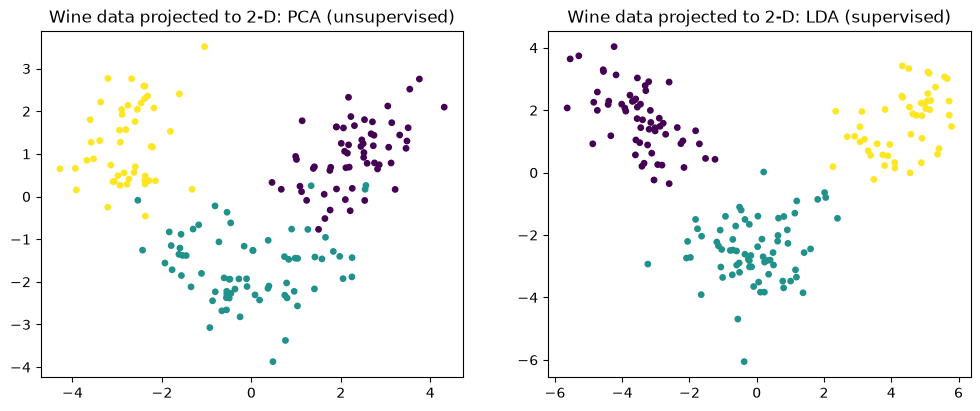

In [5]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
Xs = StandardScaler().fit_transform(X)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, (name, Z) in zip(axes, [("PCA (unsupervised)", PCA(2).fit_transform(Xs)), ("LDA (supervised)", LinearDiscriminantAnalysis(n_components=2).fit_transform(Xs, y))]):
    ax.scatter(*Z.T, c=y, cmap="viridis", s=15); ax.set_title(f"Wine data projected to 2-D: {name}")
plt.show()

## **6. Small Samples: Shrinkage**
With $p$ features, each class covariance needs $p(p+1)/2$ parameters. With few samples it becomes singular or noisy. **Ledoit-Wolf shrinkage** pulls the covariance towards a diagonal; a lifesaver for hyperspectral data with few training pixels.

In [6]:
p_feat = 60
Xh = np.vstack([rng.multivariate_normal(rng.normal(0, 0.4, p_feat), np.eye(p_feat) + 0.5, 300) for _ in range(3)]); yh = np.repeat([0, 1, 2], 300)
for n_per_class in [25, 50, 100, 250]:
    idx = np.concatenate([np.flatnonzero(yh == c)[:n_per_class] for c in range(3)])
    test = np.setdiff1d(np.arange(len(yh)), idx)
    res = {}
    for name, m in {"QDA + shrinkage": QuadraticDiscriminantAnalysis(solver="eigen", shrinkage="auto"), "LDA": LinearDiscriminantAnalysis(solver="lsqr"),
                    "LDA + Ledoit-Wolf shrinkage": LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto"), "Gaussian NB": GaussianNB()}.items():
        res[name] = m.fit(Xh[idx], yh[idx]).score(Xh[test], yh[test])
    print(f"n = {n_per_class:>3}/class: " + " | ".join(f"{k} {v:.3f}" for k, v in res.items()))

n =  25/class: QDA + shrinkage 0.794 | LDA 0.753 | LDA + Ledoit-Wolf shrinkage 0.922 | Gaussian NB 0.661
n =  50/class: QDA + shrinkage 0.797 | LDA 0.907 | LDA + Ledoit-Wolf shrinkage 0.924 | Gaussian NB 0.736
n = 100/class: QDA + shrinkage 0.802 | LDA 0.930 | LDA + Ledoit-Wolf shrinkage 0.937 | Gaussian NB 0.765
n = 250/class: QDA + shrinkage 0.873 | LDA 0.967 | LDA + Ledoit-Wolf shrinkage 0.967 | Gaussian NB 0.933


# **Part 2: Going Deeper**

### Generative vs discriminative (Ng & Jordan, 2002)
Generative models reach their (lower) asymptotic error with **fewer** samples; discriminative models (logistic regression) reach a **better** asymptote when the generative assumptions are wrong.

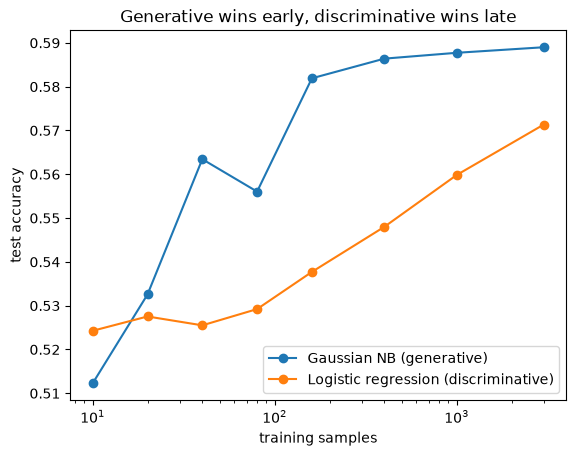

In [7]:
from sklearn.linear_model import LogisticRegression
Xg = np.vstack([rng.multivariate_normal(np.zeros(20) + 0.25 * c, 0.5 * np.eye(20) + 0.5, 3000) for c in range(2)]); yg = np.repeat([0, 1], 3000)
Xg_tr, Xg_te, yg_tr, yg_te = train_test_split(Xg, yg, test_size=0.5, stratify=yg, random_state=0)
sizes = [10, 20, 40, 80, 160, 400, 1000, 3000]
curves = {"Gaussian NB (generative)": [], "Logistic regression (discriminative)": []}
for nn_ in sizes:
    accs = {k: [] for k in curves}
    for rep in range(15):
        i = rng.choice(len(yg_tr), nn_, replace=False)
        if len(np.unique(yg_tr[i])) < 2: continue
        accs["Gaussian NB (generative)"].append(GaussianNB().fit(Xg_tr[i], yg_tr[i]).score(Xg_te, yg_te))
        accs["Logistic regression (discriminative)"].append(LogisticRegression(max_iter=2000).fit(Xg_tr[i], yg_tr[i]).score(Xg_te, yg_te))
    for k in curves: curves[k].append(np.mean(accs[k]))
for k, v in curves.items(): plt.semilogx(sizes, v, "o-", label=k)
plt.xlabel("training samples"); plt.ylabel("test accuracy"); plt.legend(); plt.title("Generative wins early, discriminative wins late"); plt.show()

### Changing priors without retraining
Generative models store $P(y)$ separately. If the class proportions in a new region are known (e.g. from statistics), plug in new priors: no retraining needed.

In [8]:
qda = QuadraticDiscriminantAnalysis(store_covariance=True).fit(X2, y2)
qda_new = QuadraticDiscriminantAnalysis(priors=[0.8, 0.1, 0.1]).fit(X2, y2)
print("Predicted class shares (equal priors)   :", np.bincount(qda.predict(X2), minlength=3) / len(y2))
print("Predicted class shares (priors .8/.1/.1):", np.bincount(qda_new.predict(X2), minlength=3) / len(y2))
print("Only ambiguous points in the overlap regions switch to class 0; well-separated points keep their class.")

Predicted class shares (equal priors)   : [0.33166667 0.36166667 0.30666667]
Predicted class shares (priors .8/.1/.1): [0.36833333 0.34166667 0.29      ]
Only ambiguous points in the overlap regions switch to class 0; well-separated points keep their class.


## **Practice Problems**
1. Show that Gaussian NB is equivalent to QDA with **diagonal** covariance matrices.
2. Apply LDA and QDA to `load_breast_cancer`. Which is better? Try `QuadraticDiscriminantAnalysis(reg_param=0.1)`.
3. Train MultinomialNB with `alpha=0.01` and `alpha=10` on the text data. How do predictions change?
4. *(Advanced)* Generate samples from the fitted QDA class Gaussians (it is a generative model!) and plot them against the real data.

QDA with diagonal covariances == Gaussian NB: True
LDA 0.96
QDA reg 0.1 0.968
QDA + shrinkage 0.94
0.01 ['flood' 'drought' 'cyclone' 'cyclone']
10 ['flood' 'drought' 'cyclone' 'cyclone']


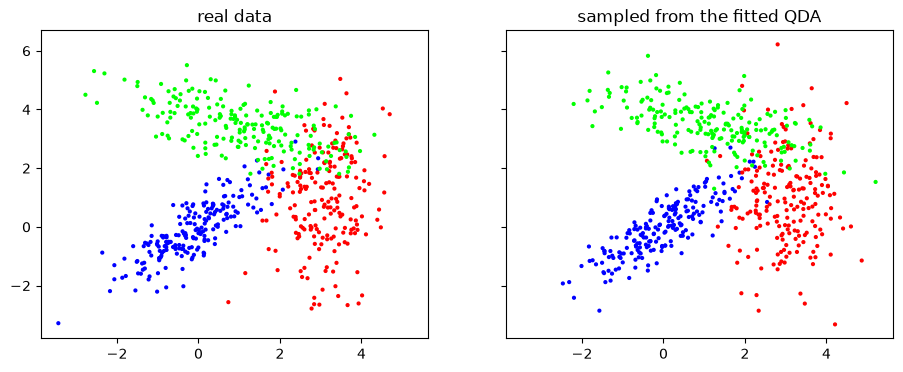

In [9]:
# Solution 1
from scipy.special import softmax
eps = 1e-9 * Xtr.var(0).max()
log_post = np.stack([np.log(np.mean(ytr == c)) + multivariate_normal(Xtr[ytr == c].mean(0), np.diag(Xtr[ytr == c].var(0) + eps)).logpdf(Xte)
                     for c in np.unique(ytr)], axis=1)
print("QDA with diagonal covariances == Gaussian NB:", np.allclose(softmax(log_post, axis=1), lib.predict_proba(Xte), atol=1e-6))
# Solution 2
from sklearn.datasets import load_breast_cancer
Xb, yb = load_breast_cancer(return_X_y=True)
# plain QDA fails here: some class covariances are singular (30 strongly collinear features)
for name, m in {"LDA": LinearDiscriminantAnalysis(), "QDA reg 0.1": QuadraticDiscriminantAnalysis(reg_param=0.1),
                "QDA + shrinkage": QuadraticDiscriminantAnalysis(solver="eigen", shrinkage="auto")}.items():
    print(name, cross_val_score(make_pipeline(StandardScaler(), m), Xb, yb, cv=5).mean().round(3))
# Solution 3
for a in [0.01, 10]:
    print(a, make_pipeline(CountVectorizer(), MultinomialNB(alpha=a)).fit(docs, labels).predict(tests + ["flood or drought cyclone"]))
# Solution 4
fake = np.vstack([rng.multivariate_normal(qda.means_[k], qda.covariance_[k], 200) for k in range(3)])
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True, sharey=True)
axes[0].scatter(*X2.T, c=y2, s=4, cmap="brg"); axes[0].set_title("real data")
axes[1].scatter(*fake.T, c=np.repeat([0, 1, 2], 200), s=4, cmap="brg"); axes[1].set_title("sampled from the fitted QDA")
plt.show()

## **Key References**
- Fisher, R. A. (1936). The use of multiple measurements in taxonomic problems. *Annals of Eugenics*, 7(2), 179-188.
- Ng, A. Y., & Jordan, M. I. (2002). On discriminative vs. generative classifiers: A comparison of logistic regression and naive Bayes. *NeurIPS 14*.
- Ledoit, O., & Wolf, M. (2004). A well-conditioned estimator for large-dimensional covariance matrices. *Journal of Multivariate Analysis*, 88(2), 365-411.
- Richards, J. A. (2022). *Remote Sensing Digital Image Analysis* (6th ed.). Springer (Maximum Likelihood Classifier).
- McCallum, A., & Nigam, K. (1998). A comparison of event models for naive Bayes text classification. *AAAI-98 Workshop on Learning for Text Categorization*.